In [ ]:
# ============================================================
# CELL 1: IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

from sklearn.ensemble import RandomForestClassifier, IsolationForest
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

In [ ]:
# ==============================
# STEP 2: LOAD DATA FROM DRIVE
# ==============================

file_path = '/content/healthcare_iot_a.csv'

df = pd.read_csv(file_path)

print(df.head())
print(df.shape)

   request_id  subject_id subject_role  subject_trust_score  patient_id  \
0           1        8270       Doctor                0.951       74065   
1           2        1860        Nurse                0.638       52745   
2           3        6390        Nurse                0.687       59542   
3           4        6191   IoT_Device                0.606       55897   
4           5        6734       Doctor                0.301       77603   

    data_type data_sensitivity  emergency_status      hospital_unit  \
0         ECG             High                 1                ICU   
1  Lab_Report              Low                 0                ICU   
2      Vitals           Medium                 0  Remote_Monitoring   
3  ICU_Stream             High                 1                ICU   
4  Lab_Report           Medium                 0                ICU   

   network_latency_ms access_decision  
0                  34          Permit  
1                 132          Permit  
2 

In [ ]:
# ============================================================
# CELL 3: PREPROCESSING
# ============================================================

# Encode categorical columns
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# Handle missing values
df.fillna(0, inplace=True)

print(df.head())

   request_id  subject_id  subject_role  subject_trust_score  patient_id  \
0           1        8270             1                0.951       74065   
1           2        1860             3                0.638       52745   
2           3        6390             3                0.687       59542   
3           4        6191             2                0.606       55897   
4           5        6734             1                0.301       77603   

   data_type  data_sensitivity  emergency_status  hospital_unit  \
0          0                 0                 1              1   
1          2                 1                 0              1   
2          4                 2                 0              2   
3          1                 0                 1              1   
4          2                 2                 0              1   

   network_latency_ms  access_decision  
0                  34                1  
1                 132                1  
2                

In [ ]:
# ============================================================
# CELL 4: FEATURE ENGINEERING
# ============================================================

X = df.drop('access_decision', axis=1)
y = df['access_decision']

# Convert target to binary (Permit=1, Deny=0)
y = (y > 0).astype(int)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# ============================================================
# CELL 5: TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train distribution:", np.unique(y_train, return_counts=True))
print("Test distribution:", np.unique(y_test, return_counts=True))

Train distribution: (array([0, 1]), array([ 8898, 12702]))
Test distribution: (array([0, 1]), array([2225, 3175]))


In [ ]:
# ============================================================
# CELL 6: BASELINE STATIC MODEL
# ============================================================

# Simple rule-based (trust threshold)
trust_index = list(df.columns).index('subject_trust_score')

threshold = 0.5

baseline_pred = (X_test[:, trust_index] > threshold).astype(int)

print("Baseline Model:")
print(classification_report(y_test, baseline_pred))

Baseline Model:
              precision    recall  f1-score   support

           0       0.48      0.76      0.59      2225
           1       0.72      0.43      0.54      3175

    accuracy                           0.57      5400
   macro avg       0.60      0.60      0.57      5400
weighted avg       0.62      0.57      0.56      5400



In [ ]:
# ============================================================
# CELL 7: RANDOM FOREST
# ============================================================

rf = RandomForestClassifier(n_estimators=200, class_weight='balanced')
rf.fit(X_train, y_train)

rf_probs = rf.predict_proba(X_test)
rf_pred = rf.predict(X_test)

print("Random Forest:")
print(classification_report(y_test, rf_pred))

Random Forest:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2225
           1       1.00      1.00      1.00      3175

    accuracy                           1.00      5400
   macro avg       1.00      1.00      1.00      5400
weighted avg       1.00      1.00      1.00      5400



In [ ]:
# ============================================================
# CELL 8: XGBOOST
# ============================================================

xgb = XGBClassifier(n_estimators=200, max_depth=6)
xgb.fit(X_train, y_train)

xgb_probs = xgb.predict_proba(X_test)
xgb_pred = xgb.predict(X_test)

print("XGBoost:")
print(classification_report(y_test, xgb_pred))

XGBoost:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2225
           1       1.00      1.00      1.00      3175

    accuracy                           1.00      5400
   macro avg       1.00      1.00      1.00      5400
weighted avg       1.00      1.00      1.00      5400



In [ ]:
# ============================================================
# CELL 9: ISOLATION FOREST
# ============================================================

iso = IsolationForest(contamination=0.1)
iso.fit(X_train)

iso_scores = iso.decision_function(X_test)

In [ ]:
# ============================================================
# CELL 10: AI-BASED RISK CALCULATION
# ============================================================

def compute_risk(i):

    # Confidence from models
    rf_conf = np.max(rf_probs[i])
    xgb_conf = np.max(xgb_probs[i])

    uncertainty = 1 - ((rf_conf + xgb_conf) / 2)

    # Normalize isolation score
    iso_norm = (iso_scores[i] - np.min(iso_scores)) / (np.max(iso_scores) - np.min(iso_scores) + 1e-6)
    iso_norm = 1 - iso_norm

    # Final risk
    trust = X_test[i][trust_index]

    risk = (uncertainty * 0.6 + iso_norm * 0.2 + (1 - trust) * 0.2)

    return risk

all_risks = [compute_risk(i) for i in range(len(X_test))]

In [ ]:
# ============================================================
# CELL 11: ACCESS CONTROL DECISION
# ============================================================

low_th = np.percentile(all_risks, 20)
high_th = np.percentile(all_risks, 50)

def decision(r):
    if r <= low_th:
        return "ALLOW"
    elif r <= high_th:
        return "RESTRICTED"
    else:
        return "DENY"

decisions = [decision(r) for r in all_risks]

print(pd.Series(decisions).value_counts(normalize=True))

DENY          0.5
RESTRICTED    0.3
ALLOW         0.2
Name: proportion, dtype: float64


In [ ]:
# ============================================================
# CELL 12: COMPARISON (BASELINE vs AI)
# ============================================================

# Convert decisions to binary
ai_binary = np.array([0 if d == "DENY" else 1 for d in decisions])

def safe_div(n, d):
    return n/d if d != 0 else 0

# Baseline
baseline_far = safe_div(np.sum((y_test==0)&(baseline_pred==1)), np.sum(y_test==0))
baseline_frr = safe_div(np.sum((y_test==1)&(baseline_pred==0)), np.sum(y_test==1))

# AI Model
ai_far = safe_div(np.sum((y_test==0)&(ai_binary==1)), np.sum(y_test==0))
ai_frr = safe_div(np.sum((y_test==1)&(ai_binary==0)), np.sum(y_test==1))

print("========= FINAL COMPARISON =========")
print("Baseline FAR:", baseline_far)
print("AI FAR:", ai_far)
print()
print("Baseline FRR:", baseline_frr)
print("AI FRR:", ai_frr)

========= FINAL COMPARISON =========
Baseline FAR: 0.23910112359550562
AI FAR: 0.35191011235955055

Baseline FRR: 0.5694488188976378
AI FRR: 0.3962204724409449


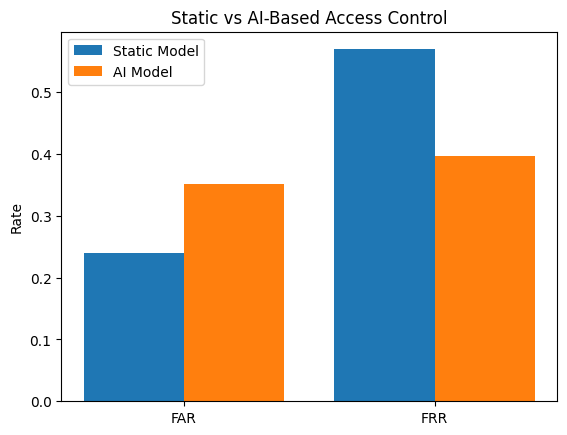

In [ ]:
# ============================================================
# CELL 13: VISUAL COMPARISON
# ============================================================

labels = ['FAR','FRR']
baseline = [baseline_far, baseline_frr]
ai = [ai_far, ai_frr]

x = np.arange(2)

plt.figure()

plt.bar(x-0.2, baseline, 0.4, label='Static Model')
plt.bar(x+0.2, ai, 0.4, label='AI Model')

plt.xticks(x, labels)
plt.ylabel("Rate")
plt.title("Static vs AI-Based Access Control")
plt.legend()

plt.show()

In [ ]:
# ============================================================
# CELL 14: ADVANCED EVALUATION METRICS
# ============================================================

from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

# -------- BASELINE METRICS --------
baseline_cm = confusion_matrix(y_test, baseline_pred)

baseline_precision = precision_score(y_test, baseline_pred)
baseline_recall = recall_score(y_test, baseline_pred)
baseline_f1 = f1_score(y_test, baseline_pred)
baseline_acc = accuracy_score(y_test, baseline_pred)

# -------- AI MODEL METRICS --------
ai_cm = confusion_matrix(y_test, ai_binary)

ai_precision = precision_score(y_test, ai_binary)
ai_recall = recall_score(y_test, ai_binary)
ai_f1 = f1_score(y_test, ai_binary)
ai_acc = accuracy_score(y_test, ai_binary)

# -------- PRINT RESULTS --------
print("========== DETAILED EVALUATION ==========\n")

print("Baseline Model:")
print("Accuracy:", round(baseline_acc, 3))
print("Precision:", round(baseline_precision, 3))
print("Recall:", round(baseline_recall, 3))
print("F1 Score:", round(baseline_f1, 3))
print("Confusion Matrix:\n", baseline_cm)

print("\nAI Model:")
print("Accuracy:", round(ai_acc, 3))
print("Precision:", round(ai_precision, 3))
print("Recall:", round(ai_recall, 3))
print("F1 Score:", round(ai_f1, 3))
print("Confusion Matrix:\n", ai_cm)

========== DETAILED EVALUATION ==========

Baseline Model:
Accuracy: 0.567
Precision: 0.72
Recall: 0.431
F1 Score: 0.539
Confusion Matrix:
 [[1693  532]
 [1808 1367]]

AI Model:
Accuracy: 0.622
Precision: 0.71
Recall: 0.604
F1 Score: 0.653
Confusion Matrix:
 [[1442  783]
 [1258 1917]]


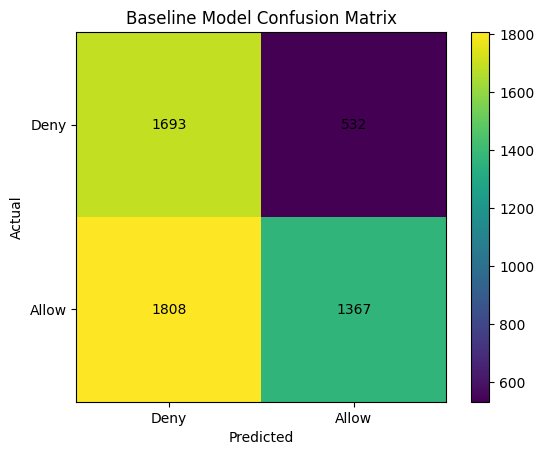

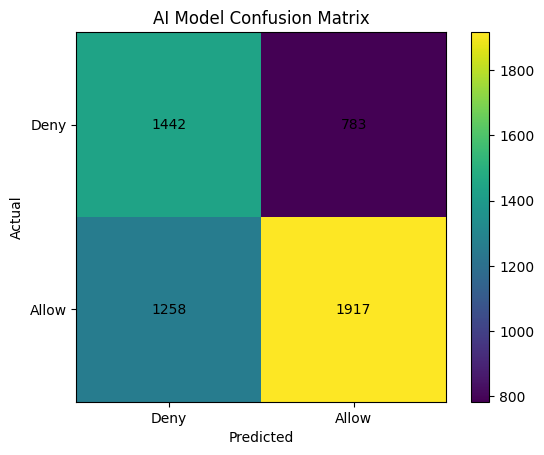

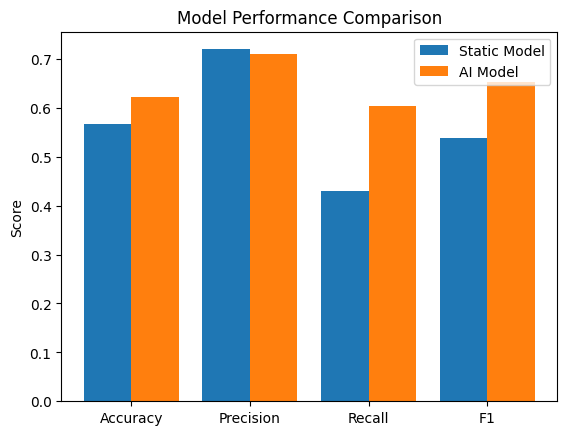

In [ ]:
# ============================================================
# CELL 15: VISUAL EVALUATION (CONFUSION MATRIX + METRICS)
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# -------- CONFUSION MATRIX PLOT FUNCTION --------
def plot_cm(cm, title):
    plt.figure()
    plt.imshow(cm)
    plt.title(title)
    plt.colorbar()

    labels = ['Deny', 'Allow']
    plt.xticks([0,1], labels)
    plt.yticks([0,1], labels)

    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i,j], ha='center', va='center')

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# -------- PLOT BOTH MATRICES --------
plot_cm(baseline_cm, "Baseline Model Confusion Matrix")
plot_cm(ai_cm, "AI Model Confusion Matrix")

# -------- METRIC COMPARISON BAR CHART --------
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']

baseline_values = [baseline_acc, baseline_precision, baseline_recall, baseline_f1]
ai_values = [ai_acc, ai_precision, ai_recall, ai_f1]

x = np.arange(len(metrics))

plt.figure()

plt.bar(x - 0.2, baseline_values, width=0.4, label='Static Model')
plt.bar(x + 0.2, ai_values, width=0.4, label='AI Model')

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.legend()

plt.show()